<a href="https://colab.research.google.com/github/rushanh1/Quantum-Networks-Quantum-Circuits/blob/main/quantum_brute_force_key_search.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install cirq --quiet
import cirq
import cirq_web
import numpy as np
import cirq_web.bloch_sphere as bloch_sphere
import matplotlib.pyplot as plt
import math

def binary_labels(num_qubits):
    return [bin(x)[2:].zfill(num_qubits) for x in range(2 ** num_qubits)]
plt.rcParams.update({'font.size': 8})

In [ ]:
n = 2 #number of qubits
qubit = cirq.NamedQubit.range(n, prefix='q')
circuit = cirq.Circuit()

circuit.append(cirq.H(qubit[0]))
circuit.append(cirq.H(qubit[1]))

for i in range(int((math.pi / 4) * math.sqrt(n))):
  #Oracle that tags the |10> state
  circuit.append(cirq.X(qubit[0]))
  circuit.append(cirq.X(qubit[1]))
  circuit.append(cirq.CZ(qubit[0], qubit[1]))
  circuit.append(cirq.X(qubit[1]))

  #Standard Diffuser found on google lol
  circuit.append(cirq.H(qubit[0]))
  circuit.append(cirq.H(qubit[1]))
  circuit.append(cirq.X(qubit[0]))
  circuit.append(cirq.X(qubit[1]))
  circuit.append(cirq.CZ(qubit[0], qubit[1]))
  circuit.append(cirq.X(qubit[0]))
  circuit.append(cirq.X(qubit[1]))
  circuit.append(cirq.H(qubit[0]))
  circuit.append(cirq.H(qubit[1]))

circuit.append(cirq.measure(qubit[0]))
circuit.append(cirq.measure(qubit[1]))

print(circuit)


q0: ───H───X───@───H───X───────@───X───H───M───
               │               │
q1: ───H───X───@───X───H───X───@───X───H───M───


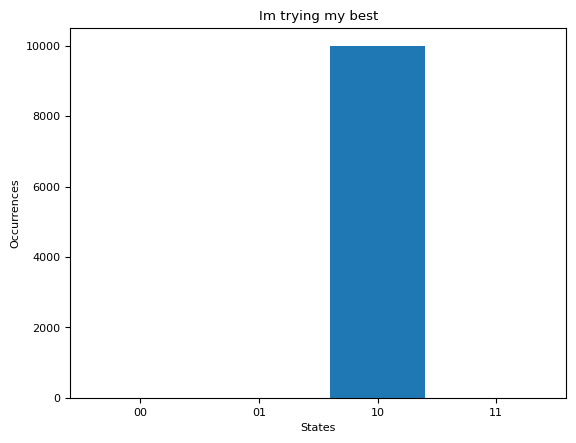

In [ ]:
#Applying the simulator

result = cirq.Simulator().run(circuit, repetitions=10000)

hist = cirq.plot_state_histogram(result, plt.subplot(), title = 'Im trying my best', xlabel = 'States', ylabel = 'Occurrences', tick_label=binary_labels(2))

plt.show()